This Jupyter notebook provides a hands-on supplement to our paper, "Directionality and quantum backfire in continuous-time quantum walks from delocalized states: exact results".

# Click here to start

In [314]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.special import jv
import scipy.sparse as sp
from math import pi
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [315]:
plt.rcParams.update({
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.titlesize': 16,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.spines.right': True,
    'axes.spines.top': True,
})

# Main code


The following codes for generating and analyzing the data were developed by José M. Villas-Bôas.

In [316]:
# Converts a site index to an array index
def site_to_idx(site, N_sites_half):
    return site + N_sites_half

# Calculates the expectation value of the position
def position_expectation(psi, sites):
    prob_density = np.abs(psi)**2
    return np.sum(sites * prob_density)

# Calculates the standard deviation
def standard_deviation(psi, sites):
    mean_x = position_expectation(psi, sites)
    mean_x2 = np.sum((sites**2) * np.abs(psi)**2)
    variance = mean_x2 - mean_x**2
    return np.sqrt(max(0, variance))

# Calculates the survival probability within a range
def calculate_survival_probability(psi, site_range, sites):
    k0, k1 = site_range
    mask = (sites >= k0) & (sites <= k1)
    return np.sum(np.abs(psi[mask])**2)


# Sets up the Hamiltonian matrix
def setup_hamiltonian(L, alpha, gamma):
    H = sp.lil_matrix((L, L), dtype=complex)
    for i in range(L - 1):
        H[i + 1, i] = -gamma * np.exp(1j * alpha)
        H[i, i + 1] = -gamma * np.exp(-1j * alpha)
    return H.tocsr()

# Creates the initial state vector
def create_initial_state(L, D, N_sites_half):
    psi0 = np.zeros(L, dtype=complex)
    psi0[site_to_idx(0, N_sites_half)] = np.sqrt(1 - D)
    psi0[site_to_idx(1, N_sites_half)] = np.sqrt(D / 2)
    psi0[site_to_idx(-1, N_sites_half)] = np.sqrt(D / 2)
    return psi0

# Runs the numerical simulation
def run_numerical_simulation(H, psi0, t_span, t_eval):
    Hi = -1j * H
    def schrodinger_rhs(t, u):
        return Hi @ u
    sol = solve_ivp(schrodinger_rhs, t_span, psi0,
                    t_eval=t_eval, atol=1e-10, rtol=1e-10, method='DOP853')
    return sol

# Calculates analytical solutions for various times
def calculate_analytical_solutions_t(sites, t_values, params):
    psi_analytical_t = []
    for i, t in enumerate(t_values):
        psi_t = np.array([psi_analytical(x, t, **params) for x in sites])
        psi_analytical_t.append(psi_t)
    print("Cálculo analítico completo.")
    return np.array(psi_analytical_t)

# Calculates the analytical wave function
def psi_analytical(x, t, alpha, gamma, D):
    z = 2 * gamma * t
    jx, jxp1, jxm1 = jv(x, z), jv(x + 1, z), jv(x - 1, z)
    return (np.sqrt(1-D) * (1.0j**x) * jx * np.exp(1j*x*alpha) +
            np.sqrt(D/2) * (1.0j**(x-1)) * jxm1 * np.exp(1j*(x-1)*alpha) +
            np.sqrt(D/2) * (1.0j**(x+1)) * jxp1 * np.exp(1j*(x+1)*alpha))

# Calculates the analytical survival probability
def P_survival(gamma, t, D, alpha):
    x = 2 * gamma * t
    term1 = jv(0, x)**2
    term2 = 2 * (1 - D * np.sin(alpha)**2) * jv(1, x)**2
    term3 = D * jv(2, x)**2
    term4 = -2 * D * np.cos(2 * alpha) * jv(0, x) * jv(2, x)
    return term1 + term2 + term3 + term4

# Calculates the analytical standard deviation
def Std_Ana(t, D, alpha, gamma):
    term_in_sqrt = D + (gamma**2 * t**2) * ((2 - D) + 2 * D * (4 * D - 3) * np.sin(alpha)**2)
    return np.sqrt(term_in_sqrt)

# Calculates the expected value of velocity
def mean_v(D, alpha, gamma):
    return 2 * gamma * np.sin(alpha) * np.sqrt(2 * D * (1 - D))

# Calculates the Mean Squared Displacement (MSD)
def MSD(t, D, alpha, gamma):
    return D + (gamma**2 * t**2) * ((2 - D) + 2 * D * np.sin(alpha)**2)

## Figure 1

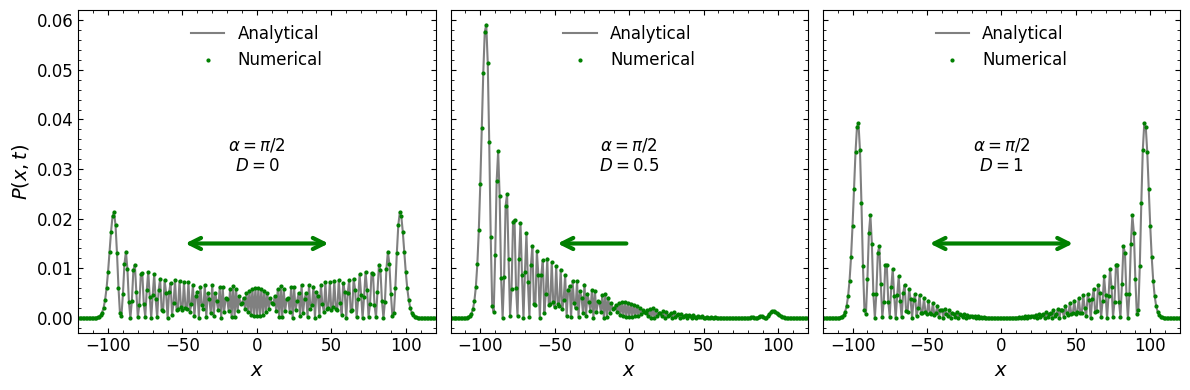

In [325]:
def plot_Prob_matplotlib():
    # Time parameters
    t_final = 50.0
    t_span = [0.0, t_final]
    t_values = np.linspace(t_span[0], t_span[1], 501)

    # Lattice sites
    N_sites_half = int(np.floor(4 * t_final))
    sites = np.arange(-N_sites_half, N_sites_half + 1)
    L = len(sites)

    # Hamiltonian and initial states
    alpha = np.pi * 0.5
    H = setup_hamiltonian(L, alpha=alpha, gamma=1.0)
    psi0_D_00 = create_initial_state(L, 0.0, N_sites_half)
    psi0_D_05 = create_initial_state(L, 0.5, N_sites_half)
    psi0_D_10 = create_initial_state(L, 1.0, N_sites_half)

    # Numerical evolution
    sol_D00 = run_numerical_simulation(H, psi0_D_00, t_span, t_values)
    sol_D05 = run_numerical_simulation(H, psi0_D_05, t_span, t_values)
    sol_D10 = run_numerical_simulation(H, psi0_D_10, t_span, t_values)

    # Analytical wavefunctions
    Psi_A_D00 = psi_analytical(sites, t_final, alpha, 1.0, 0.0)
    Psi_A_D05 = psi_analytical(sites, t_final, alpha, 1.0, 0.5)
    Psi_A_D10 = psi_analytical(sites, t_final, alpha, 1.0, 1.0)

    # Final numerical states
    psi_num_final_D00 = sol_D00.y[:, -1]
    psi_num_final_D05 = sol_D05.y[:, -1]
    psi_num_final_D10 = sol_D10.y[:, -1]

    # Figure layout
    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

    # --- Plot for D = 0.0 ---
    axes[0].plot(sites, np.abs(Psi_A_D00)**2, label='Analytical', color='gray')
    axes[0].plot(sites, np.abs(psi_num_final_D00)**2, 'o', markersize=2, label='Numerical', color='green')
    axes[0].set_xlabel(r'$x$')
    axes[0].set_ylabel(r'$P(x,t)$')
    axes[0].legend(loc='upper center', frameon=False)
    axes[0].set_xlim([-120, 120])

    x_center = 0
    y_arrow1 = 0.015

    axes[0].annotate(
        '', xy=(x_center - 50, y_arrow1), xytext=(x_center + 50, y_arrow1),
        arrowprops=dict(
            arrowstyle='<->',
            color='green',
            linewidth=3,
            mutation_scale=20
        ),
        zorder=5
    )

    axes[0].text(
        0.5, 0.5,
        r'$\alpha=\pi/2$' + '\n' + r'$D=0$',
        transform=axes[0].transAxes,
        fontsize=12,
        ha='center'
    )

    # --- Plot for D = 0.5 ---
    axes[1].plot(sites, np.abs(Psi_A_D05)**2, label='Analytical', color='gray')
    axes[1].plot(sites, np.abs(psi_num_final_D05)**2, 'o', markersize=2, label='Numerical', color='green')
    axes[1].set_xlabel(r'$x$')
    axes[1].legend(loc='upper center', frameon=False)
    axes[1].set_xlim([-120, 120])

    axes[1].annotate(
        '', xy=(x_center - 50, y_arrow1), xytext=(x_center, y_arrow1),
        arrowprops=dict(
            arrowstyle='->',
            color='green',
            linewidth=3,
            mutation_scale=20
        ),
        zorder=5
    )

    axes[1].text(
        0.5, 0.5,
        r'$\alpha=\pi/2$' + '\n' + r'$D=0.5$',
        transform=axes[1].transAxes,
        fontsize=12,
        ha='center'
    )

    # --- Plot for D = 1.0 ---
    axes[2].plot(sites, np.abs(Psi_A_D10)**2, label='Analytical', color='gray')
    axes[2].plot(sites, np.abs(psi_num_final_D10)**2, 'o', markersize=2, label='Numerical', color='green')
    axes[2].set_xlabel(r'$x$')
    axes[2].legend(loc='upper center', frameon=False)
    axes[2].set_xlim([-120, 120])

    y_arrow1 = 0.015

    axes[2].annotate(
        '', xy=(x_center - 50, y_arrow1), xytext=(x_center + 50, y_arrow1),
        arrowprops=dict(
            arrowstyle='<->',
            color='green',
            linewidth=3,
            mutation_scale=20
        ),
        zorder=5
    )

    axes[2].text(
        0.5, 0.5,
        r'$\alpha=\pi/2$' + '\n' + r'$D=1$',
        transform=axes[2].transAxes,
        fontsize=12,
        ha='center'
    )

    # Final rendering
    plt.tight_layout()
    plt.show()

plot_Prob_matplotlib()


## Figure 2

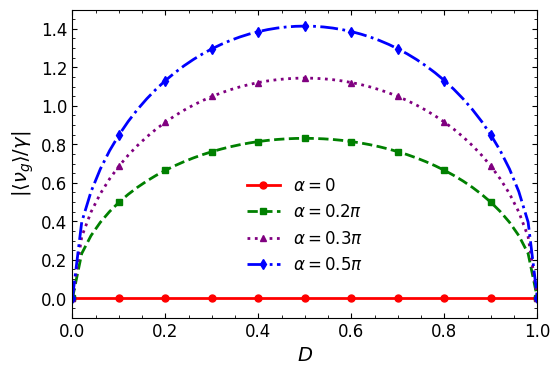

In [326]:
def Plot_Mean_v_matplotlib():
    # Parameter sweep for D
    Dv = np.linspace(0, 1, 51)
    mean_v_a0 = mean_v(Dv, 0, 1.0)
    mean_v_a02 = mean_v(Dv, 0.2*np.pi, 1.0)
    mean_v_a03 = mean_v(Dv, 0.3*np.pi, 1.0)
    mean_v_a05 = mean_v(Dv, 0.5*np.pi, 1.0)

    # Data arrays and labels
    dados = [mean_v_a0, mean_v_a02, mean_v_a03, mean_v_a05]
    labels = [r"$\alpha=0$", r"$\alpha=0.2\pi$", r"$\alpha=0.3\pi$", r"$\alpha=0.5\pi$"]

    # Line styles
    estilos = [
        ('red', '-', 'o'),
        ('green', '--', 's'),
        ('purple', ':', '^'),
        ('blue', '-.', 'd')
    ]

    # Figure setup
    plt.figure(figsize=(6, 4))
    ax = plt.gca()

    # Plot curves
    for i, (data, label) in enumerate(zip(dados, labels)):
        color, ls, marker = estilos[i]
        plt.plot(
            Dv,
            data,
            label=label,
            color=color,
            linestyle=ls,
            marker=marker,
            markersize=5,
            linewidth=2,
            markevery=int(len(Dv) / 10)
        )

    # Axis labels and limits
    plt.xlabel(r'$D$')
    plt.ylabel(r"$|\langle \nu_g \rangle/\gamma|$")
    plt.xlim(0, 1)
    plt.ylim(-0.1, 1.5)

    # Legend
    plt.legend(loc='center', bbox_to_anchor=(0.5, 0.3), ncol=1, frameon=False)

    # Render plot
    plt.show()

# Execute plot function
Plot_Mean_v_matplotlib()


## Figure 3

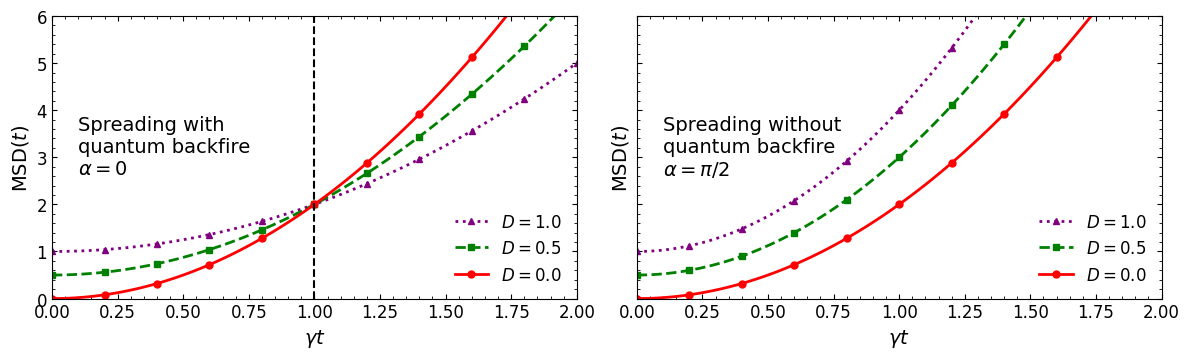

In [327]:
def Plot_MSD_vs_t2_matplotlib():
    # Parameters
    gamma = 1.0
    tv = np.linspace(0, 2, 101)
    D_vals = [0.0, 0.5, 1.0]

    # Figure setup
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.7), sharey=True)

    # Plot style dictionary
    estilos = {
        0.0: {'color': 'red', 'ls': '-', 'marker': 'o'},
        0.5: {'color': 'green', 'ls': '--', 'marker': 's'},
        1.0: {'color': 'purple', 'ls': ':', 'marker': '^'}
    }

    # Subplot for alpha = 0
    ax0 = axes[0]

    for D in sorted(D_vals, reverse=True):
        msd_vals = MSD(tv, D, 0.0, gamma)
        style = estilos[D]

        ax0.plot(
            tv,
            msd_vals,
            label=rf"$D={D}$",
            color=style['color'],
            linestyle=style['ls'],
            marker=style['marker'],
            markersize=5,
            linewidth=2,
            markevery=int(len(tv) / 10)
        )

    ax0.axvline(x=1.0, color='black', linestyle='--')

    ax0.set_xlabel(r'$\gamma t$')
    ax0.set_ylabel(r"$\mathrm{MSD}(t)$")

    # In-figure title
    ax0.text(
        0.05,
        0.65,
        'Spreading with\nquantum backfire \n' + r'$\alpha=0$',
        transform=ax0.transAxes,
        fontsize=14,
        verticalalignment='top',
        horizontalalignment='left',
        color='black'
    )

    ax0.legend(loc='lower right', frameon=False)
    ax0.set_ylim(0, 6)
    ax0.set_xlim(0, 2)

    # Subplot for alpha = pi/2
    ax1 = axes[1]
    ax1.set_xlabel(r'$\gamma t$')
    ax1.set_ylabel(r"$\mathrm{MSD}(t)$")

    for D in sorted(D_vals, reverse=True):
        msd_vals = MSD(tv, D, np.pi/2, gamma)
        style = estilos[D]
        axes[1].plot(
            tv,
            msd_vals,
            label=rf"$D={D}$",
            color=style['color'],
            linestyle=style['ls'],
            marker=style['marker'],
            markersize=5,
            linewidth=2,
            markevery=int(len(tv) / 10)
        )

    # In-figure title
    ax1.text(
        0.05,
        0.65,
        'Spreading without\nquantum backfire \n' + r'$\alpha=\pi/2$',
        transform=ax1.transAxes,
        fontsize=14,
        verticalalignment='top',
        horizontalalignment='left',
        color='black'
    )

    axes[1].legend(loc='lower right', frameon=False)
    axes[1].set_ylim(0, 6)
    axes[1].set_xlim(0, 2)

    plt.tight_layout()
    plt.show()

Plot_MSD_vs_t2_matplotlib()


## Figure 4

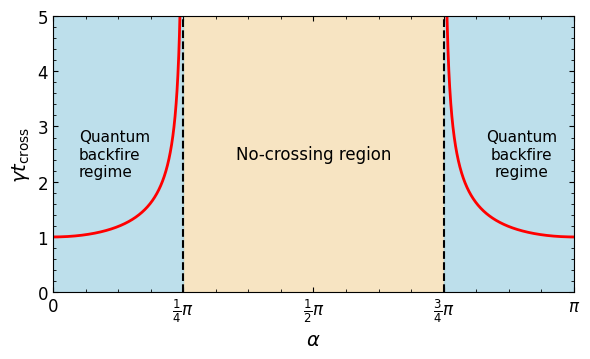

In [328]:
def Plot_tcross_vs_alpha_simplified():
    # Parameters
    eps = 1e-3
    npts = 600
    a1 = np.linspace(0, np.pi/4 - eps, npts)
    a2 = np.linspace(3*np.pi/4 + eps, np.pi - eps, npts)

    # Crossing times
    t1 = 1.0 / np.sqrt(1.0 - 2.0 * np.sin(a1)**2)
    t2 = 1.0 / np.sqrt(1.0 - 2.0 * np.sin(a2)**2)

    y_max = 5

    # Figure setup
    plt.figure(figsize=(6, 3.7))
    ax = plt.gca()

    # Background regions
    ax.axvspan(np.pi/4, 3*np.pi/4, color='wheat', alpha=0.8, label='No-crossing region')
    ax.axvspan(0, np.pi/4, color='lightblue', alpha=0.8)
    ax.axvspan(3*np.pi/4, np.pi, color='lightblue', alpha=0.8)

    # Curves
    plt.plot(a1, t1, color='red', linewidth=2)
    plt.plot(a2, t2, color='red', linewidth=2)

    # Asymptotes
    plt.axvline(x=np.pi/4, color='black', linestyle='dashed')
    plt.axvline(x=3*np.pi/4, color='black', linestyle='dashed')

    # In-figure labels
    ax.text(
        0.05,
        0.5,
        'Quantum\nbackfire\nregime',
        transform=ax.transAxes,
        fontsize=11,
        ha='left',
        va='center'
    )

    ax.text(
        0.5,
        0.5,
        'No-crossing region',
        transform=ax.transAxes,
        fontsize=12,
        ha='center',
        va='center'
    )

    ax.text(
        0.9,
        0.5,
        'Quantum\nbackfire\nregime',
        transform=ax.transAxes,
        fontsize=11,
        ha='center',
        va='center'
    )

    # Axis ticks
    ax.set_xticks([0, np.pi/4, np.pi/2, 3*np.pi/4, np.pi])
    ax.set_xticklabels(['0', r'$\frac{1}{4}\pi$', r'$\frac{1}{2}\pi$', r'$\frac{3}{4}\pi$', r'$\pi$'])

    plt.xlabel(r'$\alpha$')
    plt.ylabel(r'$\gamma t_{\mathrm{cross}}$')
    plt.ylim(0, y_max)
    plt.xlim(0, np.pi)

    plt.tight_layout()
    plt.show()

Plot_tcross_vs_alpha_simplified()


## Figure 5

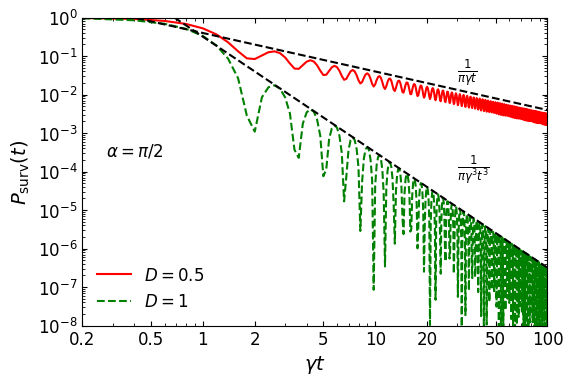

In [329]:
def Plot_Survival_Probability_matplotlib():
    # Time and parameters
    tv = np.linspace(0.2, 100, 500)
    gamma = 1.0
    alpha = np.pi / 2

    # Survival probability curves
    P_survival_10 = P_survival(gamma, tv, 1.0, alpha)
    P_survival_05 = P_survival(gamma, tv, 0.5, alpha)
    P_survival_00 = P_survival(gamma, tv, 0.0, alpha)

    # Figure setup
    plt.figure(figsize=(6, 4))

    # Plot curves
    plt.plot(tv, P_survival_05, label=r'$D=0.5$', color='red')
    plt.plot(tv, P_survival_10, linestyle='--', label=r'$D=1$', color='green')
    plt.plot(tv, 1.0/(np.pi*tv**3), linestyle='dashed', color='black')
    plt.plot(tv, 5.0/(4*np.pi*tv), linestyle='dashed', color='black')

    # Log scales
    plt.xscale('log')
    plt.yscale('log')

    # In-figure annotations
    plt.text(
        30, 3e-2,
        r'$\frac{1}{\pi\gamma t}$',
        fontsize=12,
        color='black'
    )

    plt.text(
        30, 1e-4,
        r'$\frac{1}{\pi\gamma^3 t^3}$',
        fontsize=12,
        color='black'
    )

    plt.text(
        0.05, 0.55,
        r'$\alpha = \pi/2$',
        transform=plt.gca().transAxes,
        fontsize=12,
        ha='left'
    )

    # Axis formatting
    ax = plt.gca()
    formatter = FuncFormatter(lambda x, pos: '{:g}'.format(x))
    ax.xaxis.set_major_formatter(formatter)
    ax.set_xticks([0.2, 0.5, 1, 2, 5, 10, 20, 50, 100])

    # Labels and limits
    plt.xlabel(r'$\gamma t$')
    plt.ylabel(r'$P_{\mathrm{surv}}(t)$')
    plt.ylim(10**(-8), 1)
    plt.xlim(0.2, 100)

    plt.legend(frameon=False)
    plt.show()


Plot_Survival_Probability_matplotlib()


# Figure 1 from Supplemental Material

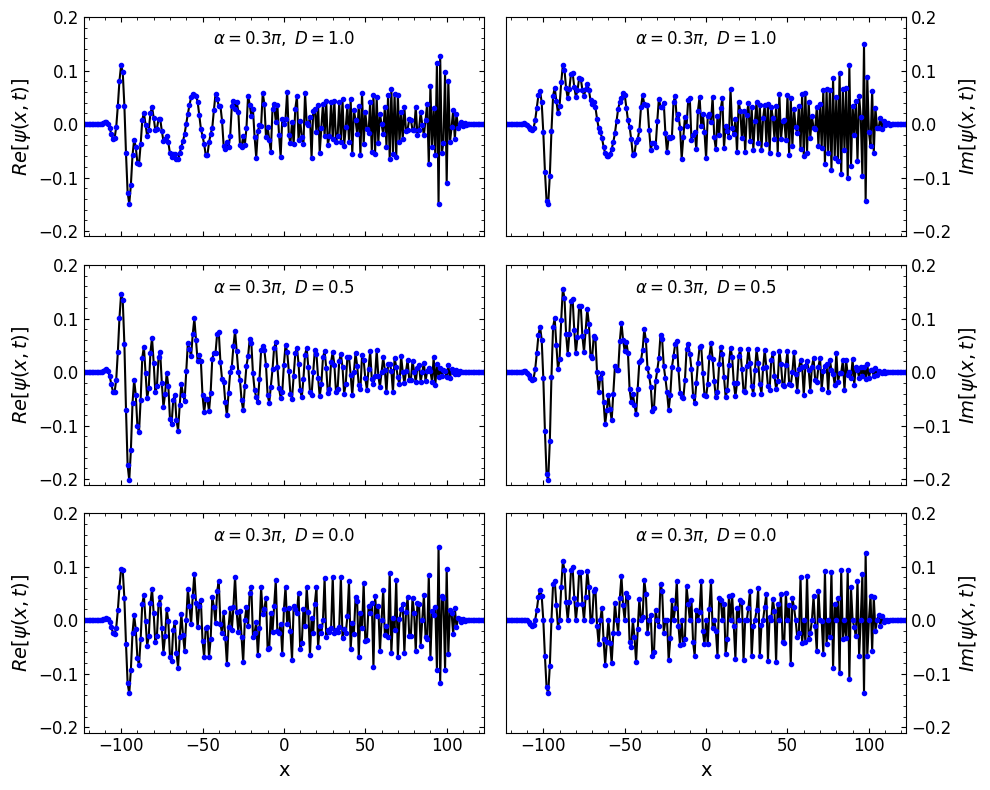

In [330]:
import numpy as np
import matplotlib.pyplot as plt

def plot_Func_matplotlib():
    # Time domain
    t_final = 50.0
    t_span = [0.0, t_final]
    t_values = np.linspace(t_span[0], t_span[1], 501)

    # Lattice sites
    N_sites_half = int(np.floor(4 * t_final))
    sites = np.arange(-N_sites_half, N_sites_half + 1)
    L = len(sites)

    # Parameters
    alpha = np.pi * 0.3
    gamma = 1.0

    # Initial states
    H = setup_hamiltonian(L, alpha=alpha, gamma=gamma)
    psi0_D_00 = create_initial_state(L, 0.0, N_sites_half)
    psi0_D_05 = create_initial_state(L, 0.5, N_sites_half)
    psi0_D_10 = create_initial_state(L, 1.0, N_sites_half)

    # Numerical solutions
    sol_D00 = run_numerical_simulation(H, psi0_D_00, t_span, t_values)
    sol_D05 = run_numerical_simulation(H, psi0_D_05, t_span, t_values)
    sol_D10 = run_numerical_simulation(H, psi0_D_10, t_span, t_values)

    psi_num_final_D00 = sol_D00.y[:, -1]
    psi_num_final_D05 = sol_D05.y[:, -1]
    psi_num_final_D10 = sol_D10.y[:, -1]

    # Analytical solutions
    Psi_A_D00 = psi_analytical(sites, t_final, alpha, gamma, 0.0)
    Psi_A_D05 = psi_analytical(sites, t_final, alpha, gamma, 0.5)
    Psi_A_D10 = psi_analytical(sites, t_final, alpha, gamma, 1.0)

    # Data list
    D_list = [
        (1.0, Psi_A_D10, psi_num_final_D10),
        (0.5, Psi_A_D05, psi_num_final_D05),
        (0.0, Psi_A_D00, psi_num_final_D00),
    ]

    # Figure setup
    fig, axes = plt.subplots(
        nrows=3, ncols=2,
        figsize=(10, 8),
        sharex=True
    )

    # Plotting loop
    for i, (Dval, PsiA, PsiN) in enumerate(D_list):
        ax_real = axes[i, 0]
        ax_imag = axes[i, 1]

        # Real part
        ax_real.plot(sites, np.real(PsiA), label="Analytical", color='black')
        ax_real.plot(sites, np.real(PsiN), label="Numerical", linestyle="", marker=".", color='blue')
        ax_real.set_ylim(-0.21, 0.20)
        ax_real.set_ylabel(r"$Re[\psi(x,t)]$")
        ax_real.text(
            0.5, 0.90,
            rf"$\alpha=0.3\pi,\ D={Dval}$",
            ha='center', va='center',
            transform=ax_real.transAxes,
            fontsize=12
        )

        # Imaginary part
        ax_imag.plot(sites, np.imag(PsiA), label="Analytical", color='black')
        ax_imag.plot(sites, np.imag(PsiN), label="Numerical", linestyle="", marker=".", color='blue')
        ax_imag.set_ylim(-0.21, 0.20)
        ax_imag.set_ylabel(r"$Im[\psi(x,t)]$")
        ax_imag.yaxis.tick_right()
        ax_imag.yaxis.set_label_position("right")
        ax_imag.set_ylabel(r"$Im[\psi(x,t)]$")
        ax_imag.text(
            0.5, 0.90,
            rf"$\alpha=0.3\pi,\ D={Dval}$",
            ha='center', va='center',
            transform=ax_imag.transAxes,
            fontsize=12
        )

        # X labels only on last row
        if i == 2:
            ax_real.set_xlabel(r"x")
            ax_imag.set_xlabel(r"x")

    plt.tight_layout()
    plt.xlim(-123, 123)
    plt.show()

# Execute
plot_Func_matplotlib()
